In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize
from scipy import stats
import statsmodels.formula.api as smf 

# Also - set up plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.style.use('fivethirtyeight')

### Binomial regression (also called logistic regression) - 
### Part 1 - changing two-alternative data into data suitable for linear regression tools

There is more detail about this topic in the textbook here: https://uob-ds.github.io/cfd2022/more-regression/logistic_regression.html

- Binomial (two-number) regression is used when we are predicting something that can only take two values
    - Dead/alive
    - Success/failure
    - Disease/no disease
    - Presence/Absence
<br>

We can't use normal linear regression techniques for this situation (see previous section notes)

<img src=SlamDunk.png align=right width=500>

# Binomial regression - Part 2

- What does a successfull predictor look like?
- What about an unsuccessful predictor?


**Can you slam-dunk a basketball?**
- Height as a predictor vs
- Love of chocolate as a predictor
    
###  Case 1 - Good predictor - Height

Text(0, 0.5, 'fail          -           success')

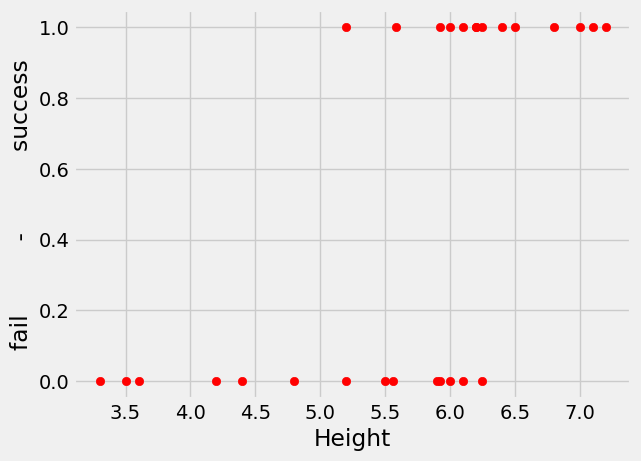

In [6]:
# make some data for height

height = np.array([3.3, 3.5, 3.6, 4.2, 4.4 ,4.8, 5.2, 5.2, 5.5, 5.56, 5.58, 5.9, 5.92, 5.92, 6.0, 6.1, 6.1, 6.0, 6.2, 6.25, 6.25, 6.2, 6.4, 6.5, 6.8, 7.1, 7.0, 7.2])
success_height =np.array([0,   0,   0,   0,   0,   0,   0,   1,   0,   0,    1,    0,   0,    1,    1,   1,   0,   0,   1,   1,    0,    1,   1,   1,   1,   1,   1,   1 ])

plt.scatter(x=height, y=success_height, color="red")
plt.xlabel("Height")
plt.ylabel("fail          -           success")

### What to notice

- Below about 5ft all values are 'fails'
- Between 5 ft and 6.5 ft there is a mix of fails and successes
- p(success) grows quickly between 5 ft and 6.5 ft
- After 6.5 feet all values are 'success'

More generally:
- Success and fail points are shifted
- Success mostly on the right, Fail on the left (or vice versa)
<br>

### Looks like height is a pretty good predictor of slam dunking success


### How can we plot that?

- Each value is 0/1 -- How can we plot the way the **probability** of dunking is changing as height increases?

</p>

- Two approaches:
  - Bin the data
  - Sliding average

In [21]:
def moving_average(my_data,window_size):
    my_data = success_height
    moving_average = np.zeros(len(my_data)-window_size+1)
    for i in np.arange(0,len(my_data)-window_size+1):
        moving_average[i] = np.sum(my_data[i:i+window_size])/window_size
    return(moving_average)

In [22]:
window_size = 5 # use odd numbers
moving_average_success = moving_average(success_height,window_size)
print(len(moving_average_success))
print(len(success_height))
print(moving_average_success)

24
28
[0.  0.  0.  0.2 0.2 0.2 0.4 0.4 0.2 0.4 0.6 0.6 0.6 0.6 0.6 0.6 0.4 0.6
 0.8 0.8 0.8 1.  1.  1. ]


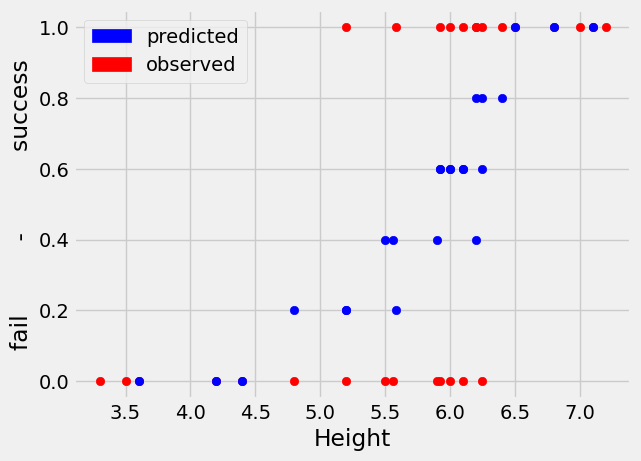

In [28]:
moving_average_pos_start = int(window_size/2)
plt.scatter(x=height, y=success_height, color="red")
# moving_average_pos_start:-1*moving_average_pos_start means
# start 2 positions after the beginning and end 2 positions from the end
# i.e. centre the average of 0-4 over 2
# centre the average of 1-5 over 3 etc.
plt.scatter(x=height[moving_average_pos_start:-1*moving_average_pos_start], y=moving_average_success, color='blue')
plt.xlabel("Height")
plt.ylabel("fail          -           success")
blue_legend = mpatches.Patch(color='blue', label = 'predicted')
red_legend = mpatches.Patch(color='red', label = 'observed')
plt.legend(handles = [blue_legend,red_legend])

### What does a bad predictor look like?

Text(0, 0.5, 'fail          -           success')

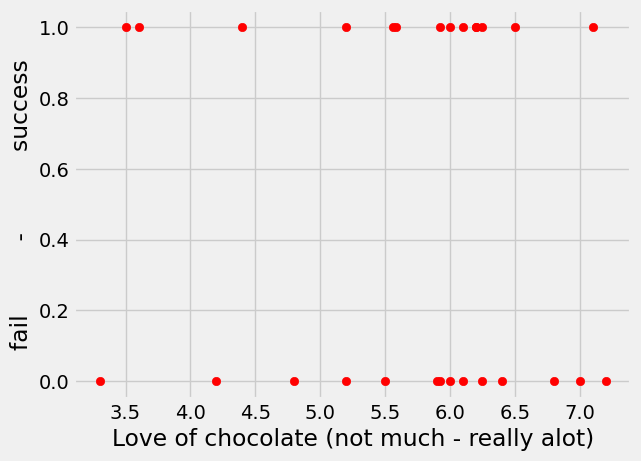

In [29]:
# make some data

love_of_chocolate = np.array([3.3, 3.5, 3.6, 4.2, 4.4 ,4.8, 5.2, 5.2, 5.5, 5.56, 5.58, 5.9, 5.92, 5.92, 6.0, 6.1, 6.1, 6.0, 6.2, 6.25, 6.25, 6.2, 6.4, 6.5, 6.8, 7.1, 7.0, 7.2])
success_chocolate =np.array([0,   1,   1,   0,   1,   0,   0,   1,   0,   1,    1,    0,   1,    0,    1,   0,   1,   0,   1,   1,    0,    1,   0,   1,   0,   1,   0,   0 ])

plt.scatter(x=love_of_chocolate, y=success_chocolate, color="red")
plt.xlabel("Love of chocolate (not much - really alot)")
plt.ylabel("fail          -           success")

### What to notice
- Points are not shifted in relationship to each other
    - i.e. one set of points mostly further right
- At any point on the x axis there are both successes and fails and about equally often

### This is what a bad predictor looks like...

### Let's predict some data - Height example

In [45]:
# Some functions we might need

# Calculate a log odds ratio from a probability value
def logit(p):
    # Apply logit transformation to probability values
    odds_ratios = p / (1 - p)
    return np.log(odds_ratios)


# start from a log odds value and back-transform to a probability value
def inv_logit(log_odds_value):
    # Reverse logit transformation to turn a log(odds ratio) value into a probability
    odds_ratios = np.exp(log_odds_value)  # Reverse the log operation.
    return odds_ratios / (odds_ratios + 1)  # Reverse odds ratios operation.


# measure the difference between actual and predicted values
# In technical terms, get the log-likelihood for one slope/intercept set of values
# The log likelihood measures the match between observed and predicted values
# see details here:  https://uob-ds.github.io/cfd2022/more-regression/logistic_regression.html
def mll_logit_cost(intercept_and_slope, x, y):
    """ Cost function for log likelihood

    Return ** -1 ** times the log of the likelihood because we want to 
    **maximize** the likelihood of our predictions given the data 
    (this measures the fit between predicted and observed values -- bad predicted values have low likelihood)
    but the function that we use is one that wants to **minimizes** things.
    """
    intercept, slope = intercept_and_slope # our current guess for the intercept and slope
    # Make predictions for sigmoid.
    predicted_log_odds = intercept + slope * x # predict a log odds value for each x
    pp_of_1 = inv_logit(predicted_log_odds) # back-convert a log odds prediction to a probability value
    # Calculate predicted probabilities of actual labels.
    # If observed value is 1, the probability of that value is our predicted p(success) [prob that value is 1]
    # If the observed value is 0, the probability of that value is (1 - p(success))
    # each observed value has a probability based on our predicted p(success)
    pp_of_labels = y * pp_of_1 + (1 - y) * (1 - pp_of_1)
    # Notice the trick -- if y = 0 then the part before the plus is zero and we use the second part for our probability
    #    if y = 1 the second part is zero and we use the first part of the equation for our probability
    #    This allows us to do the same thing as an 'if' statement without the 'if'
    #    i.e. this is essentially the same as: 
    #       if y == 0: 
    #           pp_of_labels = (1 - pp_of 1) 
    #.      else:
    #.          pp_of_labels = pp_of_1
    #    but we do it without using an 'if' statement.  
    #.   We use this for y=0/1, but it can also
    #    work for intermediate values if needed - left as an exercise)
    
    # Sum the values - this reflects the likelihood of the predictions for all of the points
    # Why take the log?  (this is different from the log we did above to convert to a continuous scale)
    # We take the log here because likelihood sums can be very small or very large and that can cause
    # problems (remember that floating point math is not exact when numbers are very big or very small)
    log_likelihood = np.sum(np.log(pp_of_labels))
    # this is the probability of _all_ of the values together

    # We want the values for slope and intercept that make our data have the **maximum** probability
    # However, we are using a **minimize** function.
    # We get the function to search for a maximum by multiplying the probability by minus 1
    # The highest positive probability will then become the lowest negative probability.

    return -log_likelihood


def predicted_logreg(intercept_and_slope, x):
    """ Convert predicted log odds values from slope/intercept linear equation into probabilities (e.g. for plotting predictions)

    """
    intercept, slope = intercept_and_slope
    # Make predictions for sigmoid.
    predicted_log_odds = intercept + slope * x
    pp_of_1 = inv_logit(predicted_log_odds)
    return pp_of_1

In [46]:
# use logreg_result on our height/dunk success data

logreg_result_height = optimize.minimize(mll_logit_cost,  # Cost function
                  [-7, 0.8],  # Guessed intercept and slope
                  args=(height, success_height),  # x and y values
                  )

logreg_result_height.x
# intercept, slope is the order of the result because 
# this is the order in the mll_logit_cost function.
# Our initial guess should also use the [intercept, slope] order
# for this result, intercept = -14.995
# slope = 2.57

array([-14.99507606,   2.57043464])

In [47]:
# get predicted y values so we can plot them
pred_y_height = predicted_logreg(logreg_result_height.x,height)
pred_y_height

array([0.00148235, 0.00247619, 0.00319964, 0.01478494, 0.02447882,
       0.0655595 , 0.16399263, 0.16399263, 0.29782313, 0.33104567,
       0.34252755, 0.54251914, 0.55524775, 0.55524775, 0.60528413,
       0.66475908, 0.66475908, 0.60528413, 0.71942652, 0.74462363,
       0.74462363, 0.71942652, 0.81087499, 0.84719252, 0.92300396,
       0.96285272, 0.95248217, 0.97102879])

### Put our predicted values on the plot

Text(0.5, 1.0, 'What a good predictor looks like')

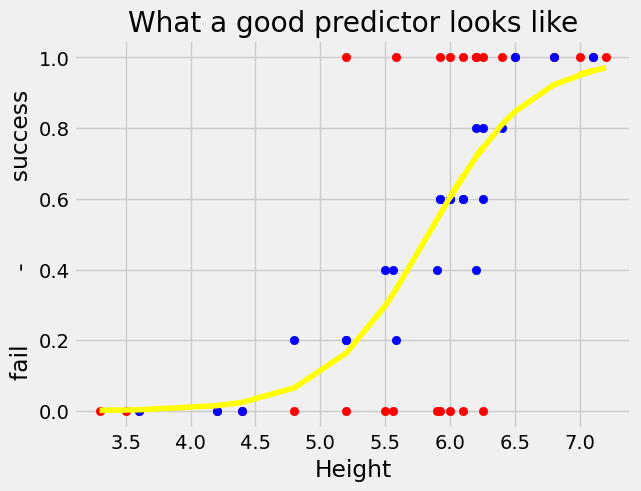

In [48]:
plt.scatter(x=height, y=success_height, color="red")
plt.plot(height,pred_y_height,color="yellow")
plt.scatter(x=height[moving_average_pos_start:-1*moving_average_pos_start], y=moving_average_success,color="blue")
plt.xlabel("Height")
plt.ylabel("fail          -           success")
plt.title("What a good predictor looks like")

### There is a clear transition from failure to success as height increases

#### A bad predictor -- Are people who love of chocolate more likely to dunk?

In [49]:
logreg_result_choc = optimize.minimize(mll_logit_cost,  # Cost function
                  [-7, 0.8],  # Guessed intercept and slope
                  args=(height, success_chocolate),  # x and y values
                  )

print(logreg_result_choc.x)

pred_y_choc = predicted_logreg(logreg_result_choc.x,height)
print(pred_y_choc)

[ 0.92743625 -0.16359213]
[0.59570054 0.58779654 0.58382723 0.55979973 0.55172204 0.53548873
 0.51917988 0.51917988 0.50691945 0.50446589 0.50364798 0.4905618
 0.48974415 0.48974415 0.48647417 0.48238836 0.48238836 0.48647417
 0.4783049  0.47626422 0.47626422 0.4783049  0.47014721 0.46607406
 0.45388389 0.44174875 0.4457868  0.43771839]


Text(0.5, 1.0, 'What a bad predictor looks like')

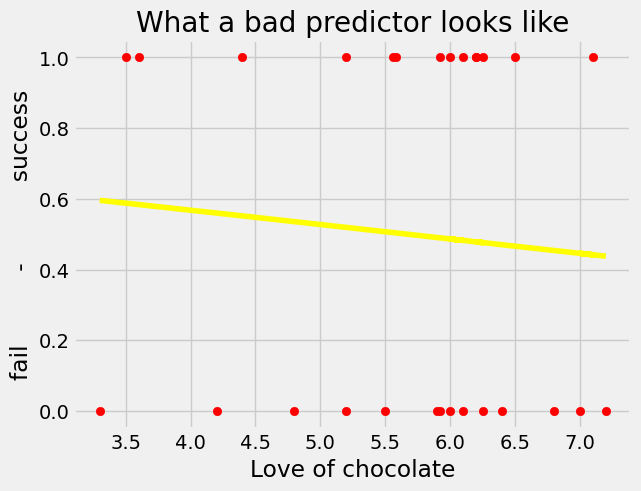

In [50]:
plt.scatter(x=height, y=success_chocolate, color="red")
plt.plot(height,pred_y_choc,color="yellow")
plt.xlabel("Love of chocolate")
plt.ylabel("fail          -           success")
plt.title("What a bad predictor looks like")

### All of the predicted values cluster in the middle

## Permutation testing
#### Testing slope and intercept:  In the usual way you can shuffle the x values (e.g. height) many times and calculate slopes and intercepts to test whether the slopes are intercepts are values that are rare in the random world
- Shuffle height values
- use optimize to calculate slope and intercept
- save slope and intercept values from simulated world
- repeat
</p>

Plot the slope distribution from simulated worlds compared to the slope from the real world
- Was the real slope unusual in a world where height is NOT related to dunking ability?

# Residuals (error in predicted values):  In some situations we have needed residuals - here is how we get them for logistic regression

In [70]:
residuals = pred_y_height - success_height
print(residuals)

[ 0.00148235  0.00247619  0.00319965  0.01478496  0.02447884  0.06555953
  0.16399268 -0.83600732  0.29782318  0.33104571 -0.65747241  0.54251915
  0.55524776 -0.44475224 -0.39471587 -0.33524093  0.66475907  0.60528413
 -0.2805735  -0.2553764   0.7446236  -0.2805735  -0.18912504 -0.15280751
 -0.07699607 -0.0371473  -0.04751785 -0.02897123]


#### Remember SSE?  Sum the squared error
Residuals are the error

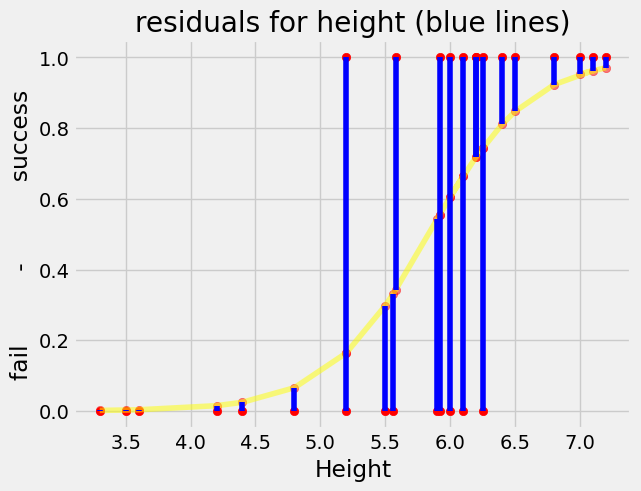

In [79]:
# plot the residuals as blue lines
plt.scatter(x=height, y=success_height, color="red")
plt.plot(height,pred_y_height,color="yellow",alpha=0.5)
plt.xlabel("Height")
plt.ylabel("fail          -           success")
plt.title("residuals for height (blue lines)")

for i in np.arange(len(residuals)):
    plt.plot([height[i], height[i]],[success[i],pred_y_height[i]],color="blue")
plt.scatter(x=height, y=pred_y_height, color="red",alpha=0.5)

#### If you scramble the Height values 
- The yellow line will be in the middle
- All of the blue values will be longer
- The yellow line will be flat

#### We can test the slope in the same way as for linear regression
- Chocolate does not predict dunking success - the slope is flat
- Height predicts dunking success - the slope is steep